# **Data Exploration**
Derrick Kyei <br>
Univesity of the Cumberlands <br>
Dr. Gamini Bulumelle <br>
MSAI 699-B01 <br>
12 July 2026

# **Introduction**
This notebook analyzes the [heart disease dataset](https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci) for preprocessing and EDA purpose. 
1. [Descriptive Statistics](#descriptive-statistics)
2. [Analyzing Categrical Features](#analyzing-categorical-features)
3. [Visualizing Data Distributions](#visualizing-data-distributions)
4. [Visualizing Categorical Feature Distributions](#visualizing-categorical-feature-distributions)
5. [Correlation Analysis](#correlation-analysis)
7. [Data Preprocessing](#data-preprocessing)
8. [Conclusion](#conclusion)

In [14]:
#Check and install packages
import os, sys
import importlib
import subprocess

def check_and_install(*packages):
    for package in packages:
        try:
            importlib.import_module(package)
        except ImportError:
            print(f"{package} is not installed. Installing...")
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', package,'--quiet'])

check_and_install('numpy', 'pandas', 'matplotlib', 'seaborn', 'kagglehub', 'ipython', 'scikit-learn')

ipython is not installed. Installing...
scikit-learn is not installed. Installing...


In [15]:
#import packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns #EDA purposes
import kagglehub

In [16]:
from kagglehub import KaggleDatasetAdapter
from IPython.display import display
file_to_load = "heart_cleveland_upload.csv"

data = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    "cherngs/heart-disease-cleveland-uci",
    file_to_load) #loads and downloads the path

## Descriptive Statistics

In this section, I look at the descriptive statistics for all numerical columns. This will give me a better understanding of the data's distribution, central tendency, and spread, helping to identify potential outliers or inconsistencies.

In [17]:
print(data.info())
missing_values = data.isnull().sum()
display(missing_values)
duplicates = data.duplicated().sum()
display(duplicates)
print("Descriptive statistics for the dataset:")
display(data.describe())
display(data)

<class 'pandas.DataFrame'>
RangeIndex: 297 entries, 0 to 296
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   age        297 non-null    int64  
 1   sex        297 non-null    int64  
 2   cp         297 non-null    int64  
 3   trestbps   297 non-null    int64  
 4   chol       297 non-null    int64  
 5   fbs        297 non-null    int64  
 6   restecg    297 non-null    int64  
 7   thalach    297 non-null    int64  
 8   exang      297 non-null    int64  
 9   oldpeak    297 non-null    float64
 10  slope      297 non-null    int64  
 11  ca         297 non-null    int64  
 12  thal       297 non-null    int64  
 13  condition  297 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 32.6 KB
None


age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalach      0
exang        0
oldpeak      0
slope        0
ca           0
thal         0
condition    0
dtype: int64

np.int64(0)

Descriptive statistics for the dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
count,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000,297.000000
mean,54.542088,0.676768,2.158249,131.693603,247.350168,0.144781,0.996633,149.599327,0.326599,1.055556,0.602694,0.676768,0.835017,0.461279
std,9.049736,0.468500,0.964859,17.762806,51.997583,0.352474,0.994914,22.941562,0.469761,1.166123,0.618187,0.938965,0.956690,0.499340
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,2.000000,120.000000,211.000000,0.000000,0.000000,133.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,56.000000,1.000000,2.000000,130.000000,243.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,0.000000,0.000000
75%,61.000000,1.000000,3.000000,140.000000,276.000000,0.000000,2.000000,166.000000,1.000000,1.600000,1.000000,1.000000,2.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,3.000000,2.000000,1.000000


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,condition
0,69,1,0,160,234,1,2,131,0,0.1,1,1,0,0
1,69,0,0,140,239,0,0,151,0,1.8,0,2,0,0
2,66,0,0,150,226,0,0,114,0,2.6,2,0,0,0
3,65,1,0,138,282,1,2,174,0,1.4,1,1,0,1
4,64,1,0,110,211,0,2,144,1,1.8,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,1,3,152,223,0,0,181,0,0.0,0,0,2,1
293,39,1,3,118,219,0,0,140,0,1.2,1,0,2,1
294,35,1,3,120,198,0,0,130,1,1.6,1,0,2,1
295,35,0,3,138,183,0,0,182,0,1.4,0,0,0,0


## Analyzing Categorical Features

Many columns appear to be categorical (e.g., `sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`, `condition`). In this column, examine the unique values and their counts for these columns to understand their distribution.

In [18]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'condition']

for col in categorical_cols:
    print(f"\nValue counts for column '{col}':")
    print(data[col].value_counts())


Value counts for column 'sex':
sex
1    201
0     96
Name: count, dtype: int64

Value counts for column 'cp':
cp
3    142
2     83
1     49
0     23
Name: count, dtype: int64

Value counts for column 'fbs':
fbs
0    254
1     43
Name: count, dtype: int64

Value counts for column 'restecg':
restecg
0    147
2    146
1      4
Name: count, dtype: int64

Value counts for column 'exang':
exang
0    200
1     97
Name: count, dtype: int64

Value counts for column 'slope':
slope
0    139
1    137
2     21
Name: count, dtype: int64

Value counts for column 'ca':
ca
0    174
1     65
2     38
3     20
Name: count, dtype: int64

Value counts for column 'thal':
thal
0    164
2    115
1     18
Name: count, dtype: int64

Value counts for column 'condition':
condition
0    160
1    137
Name: count, dtype: int64


## Visualizing Data Distributions

Visualizations are crucial for understanding data distributions, identifying outliers, and uncovering relationships. In this section, I use `matplotlib` and `seaborn` for this purpose.

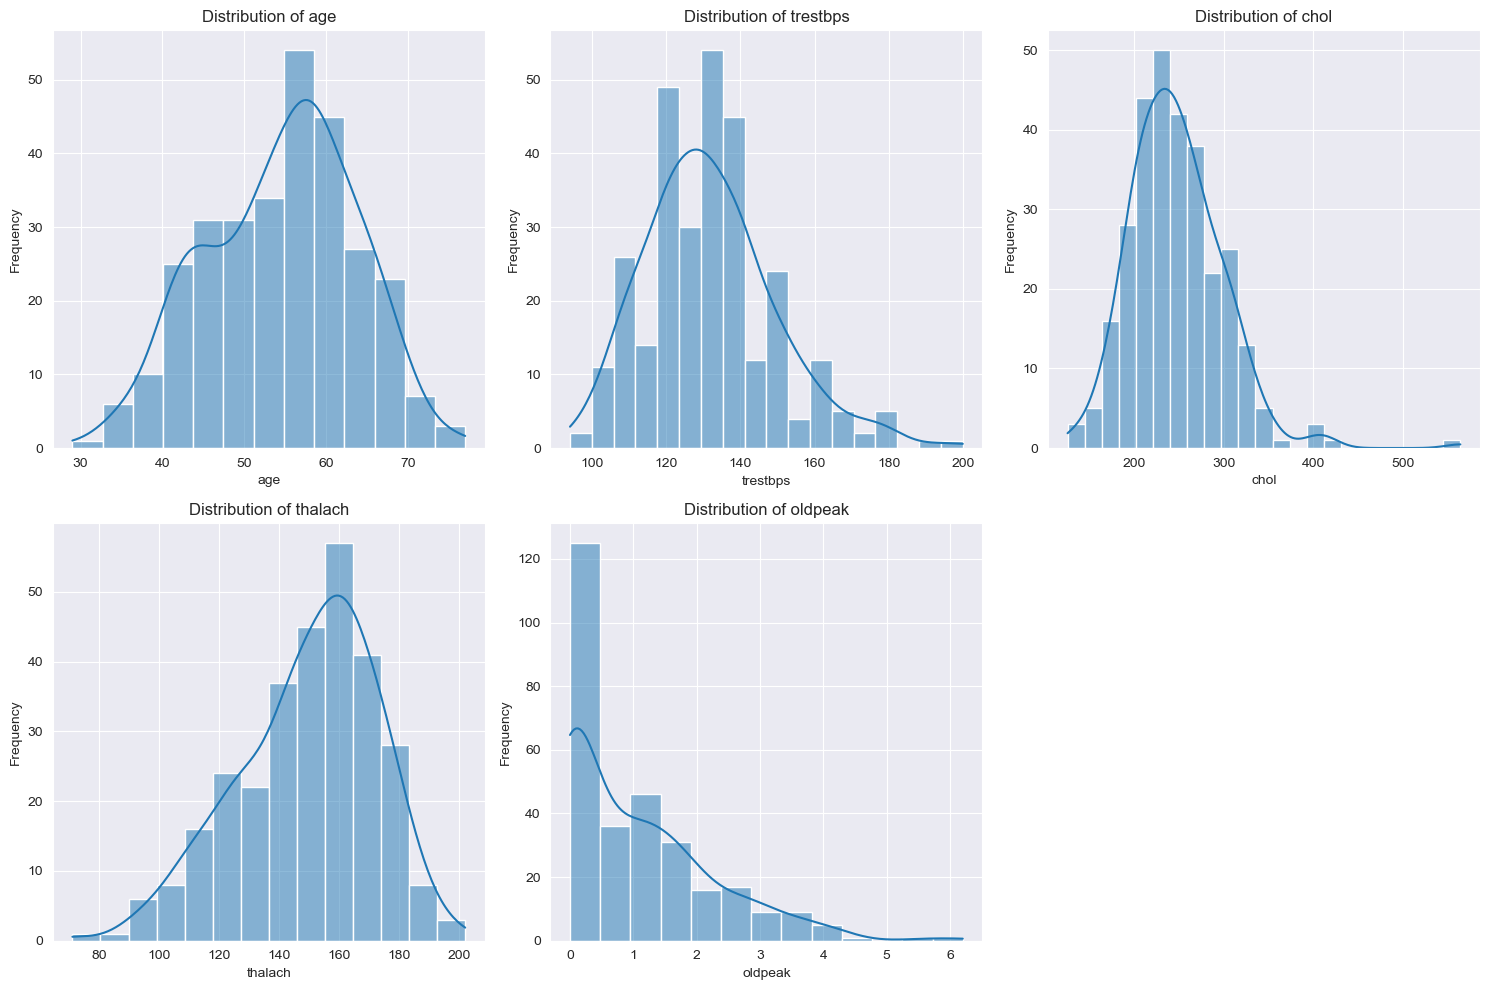

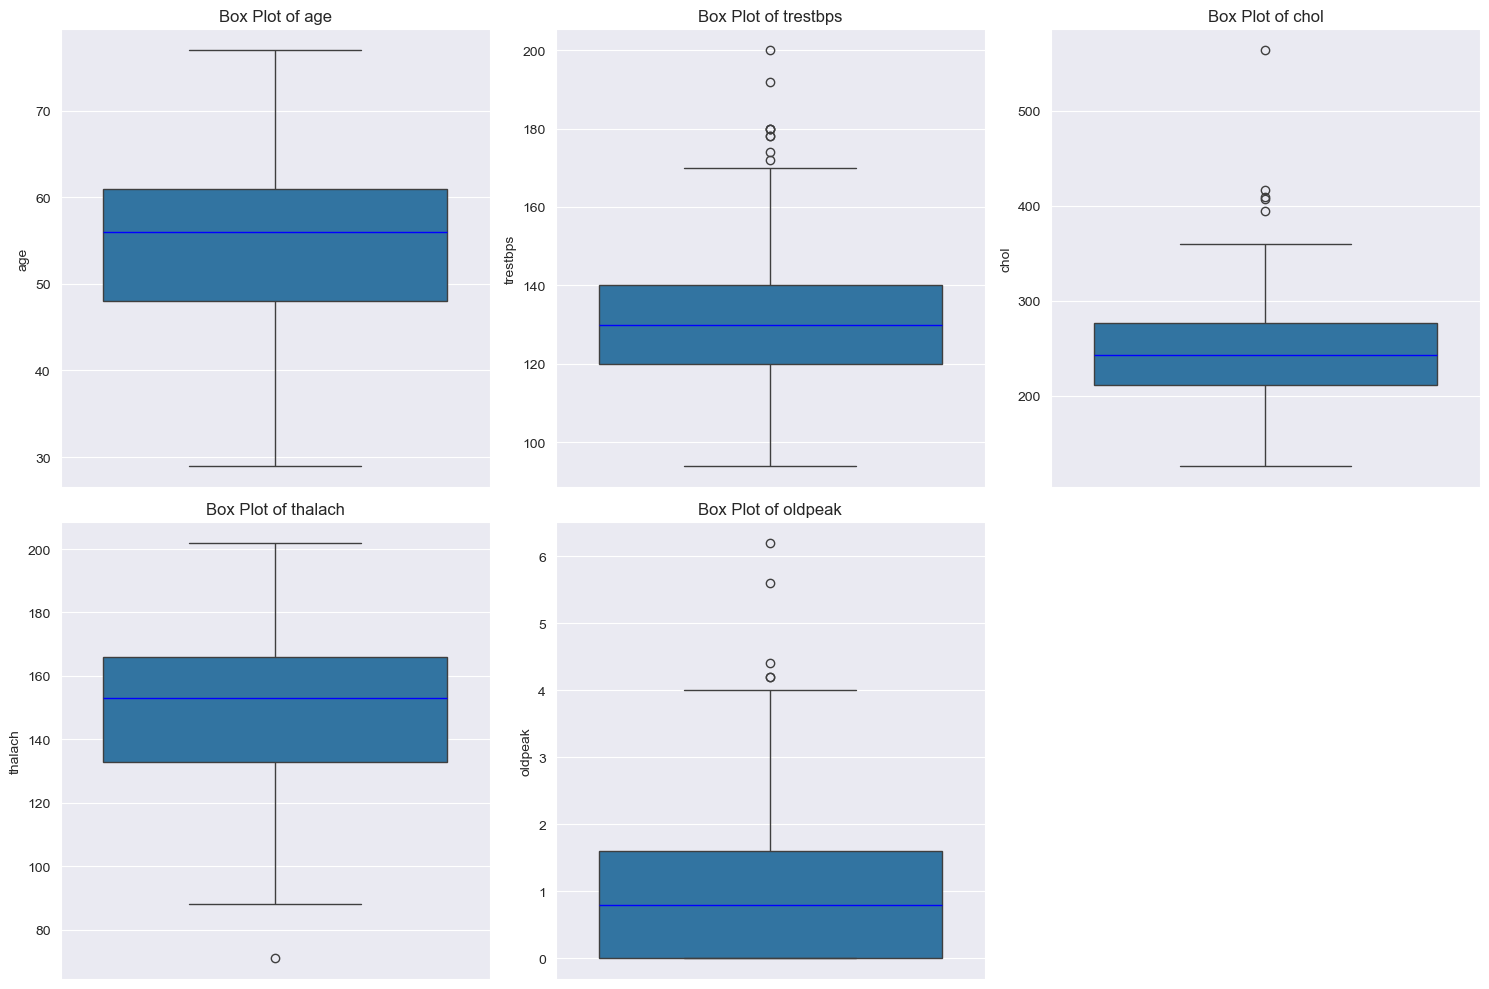

In [19]:
# Set style for plots
sns.set_style("darkgrid")

# List of numerical columns to visualize
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i) # 2 rows, 3 columns
    sns.histplot(data[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=data[col], medianprops={'color': 'blue'}, meanprops={"marker": "o", "markerfacecolor": "yellow", "markeredgecolor": "black"})
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

## Visualizing Categorical Feature Distributions

In this section, I visualize the distribution of our identified categorical features.

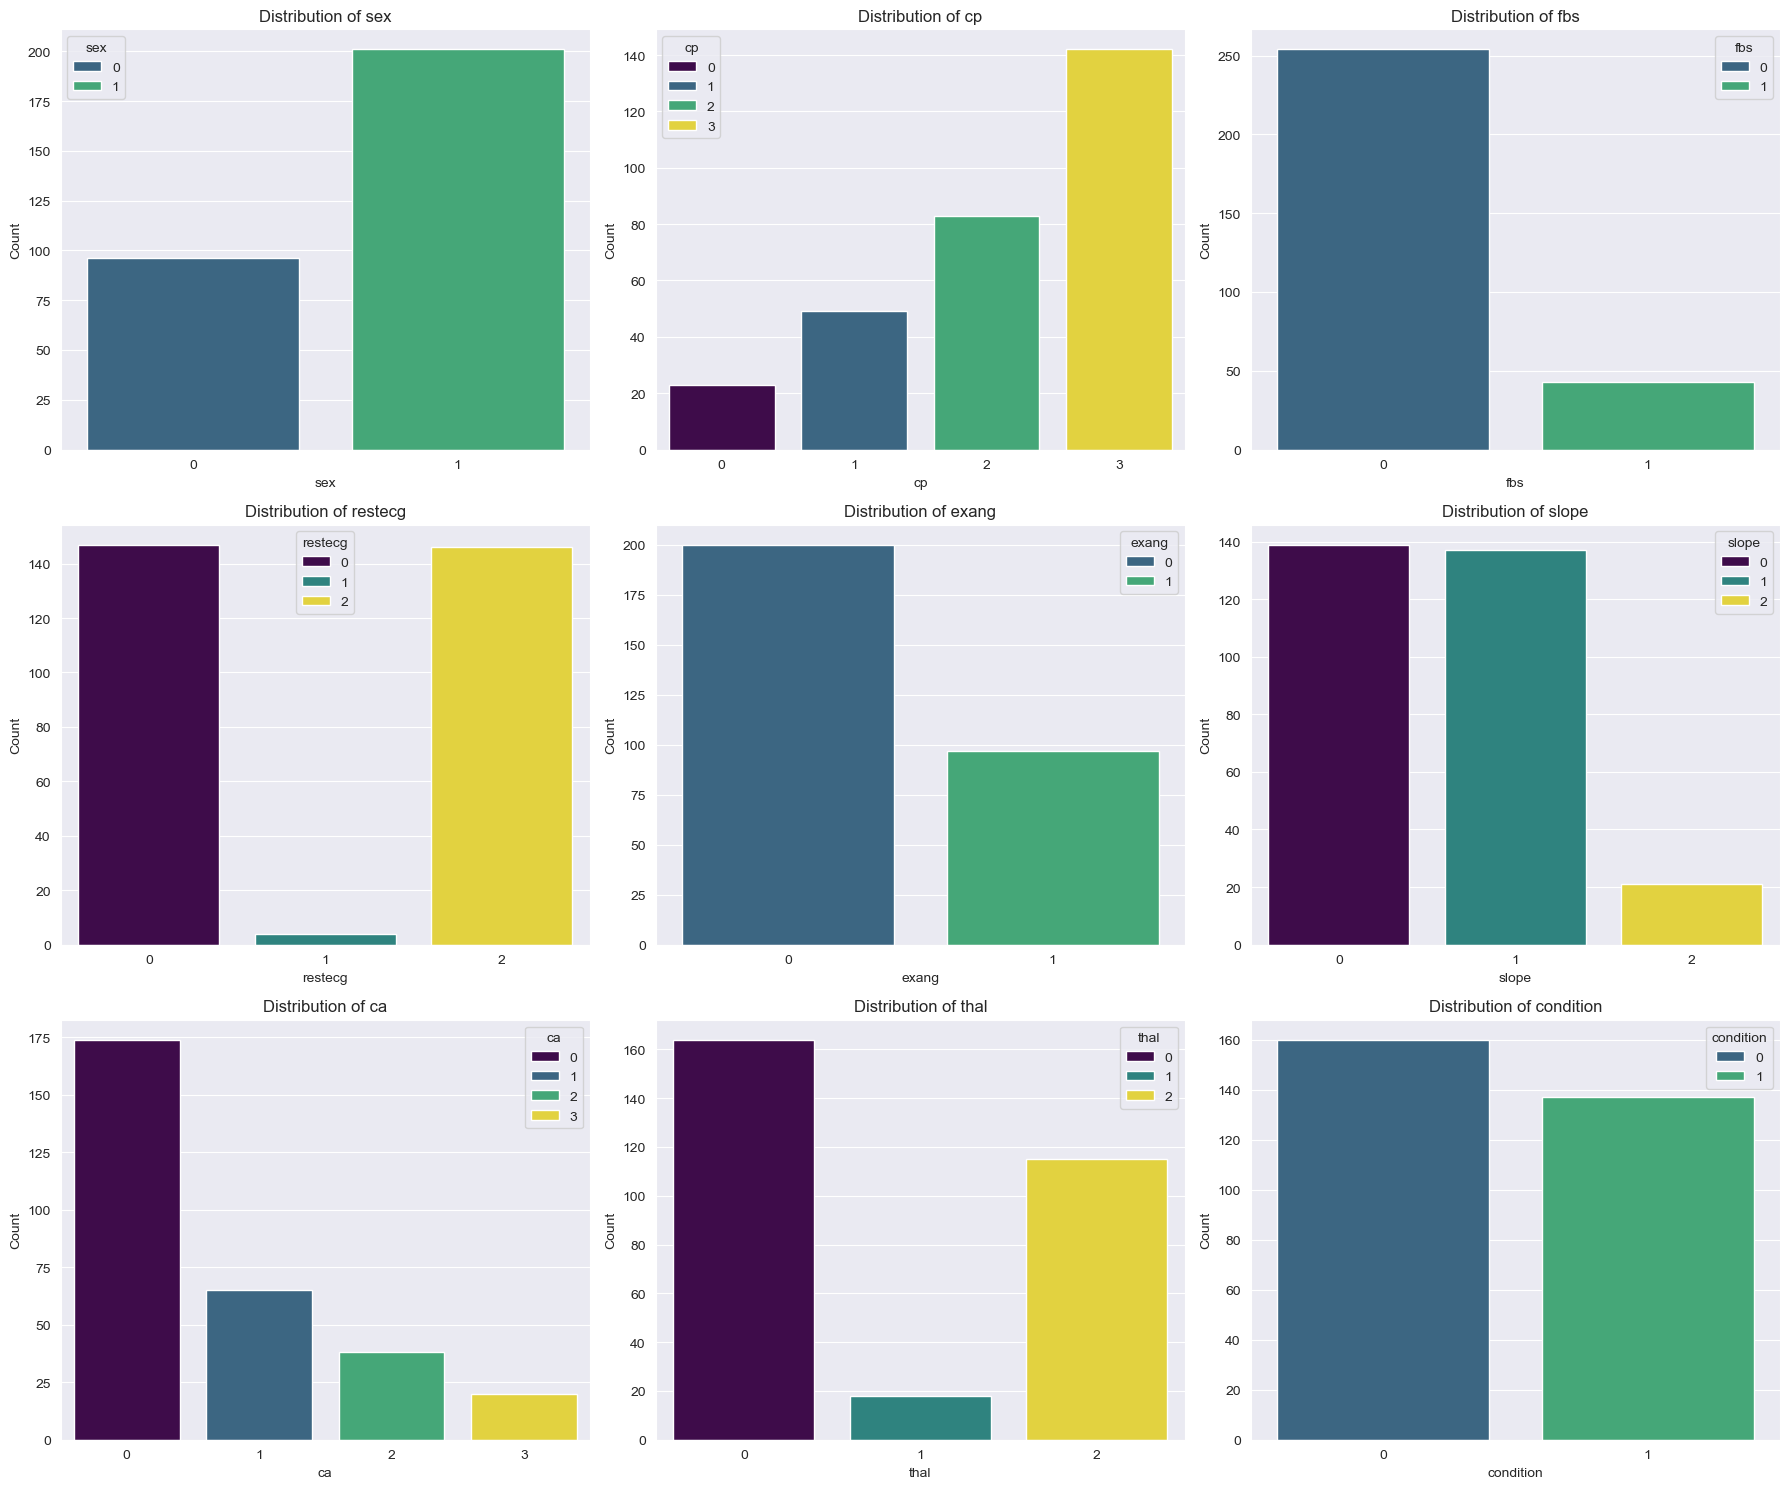

In [20]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'condition']

plt.figure(figsize=(18, 15))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 3, i) # 3 rows, 3 columns
    sns.countplot(x=data[col], hue=data[col],palette='viridis', legend=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Correlation Analysis

Understanding the correlation betIen features and the target variable is vital for feature selection and building predictive models. In this section, I compute and visualize the correlation matrix.

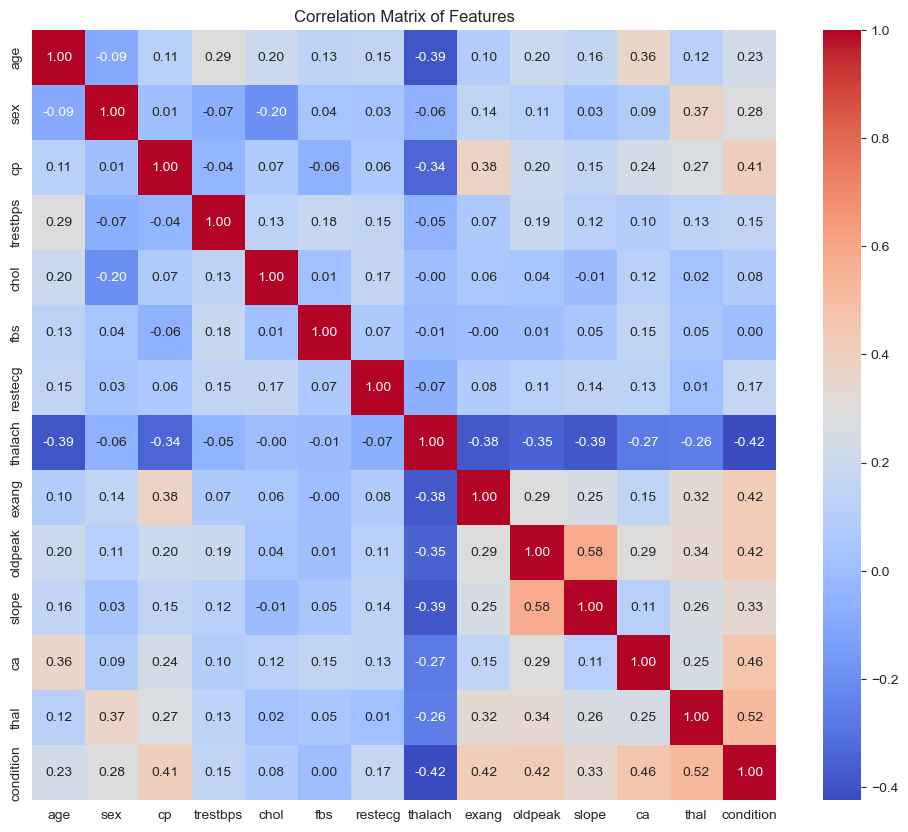

In [21]:
plt.figure(figsize=(12, 10))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

## Relationship with Target Variable

In this section, I specifically look at how each feature correlates with the `condition` variable to identify the most influential predictors of heart disease.

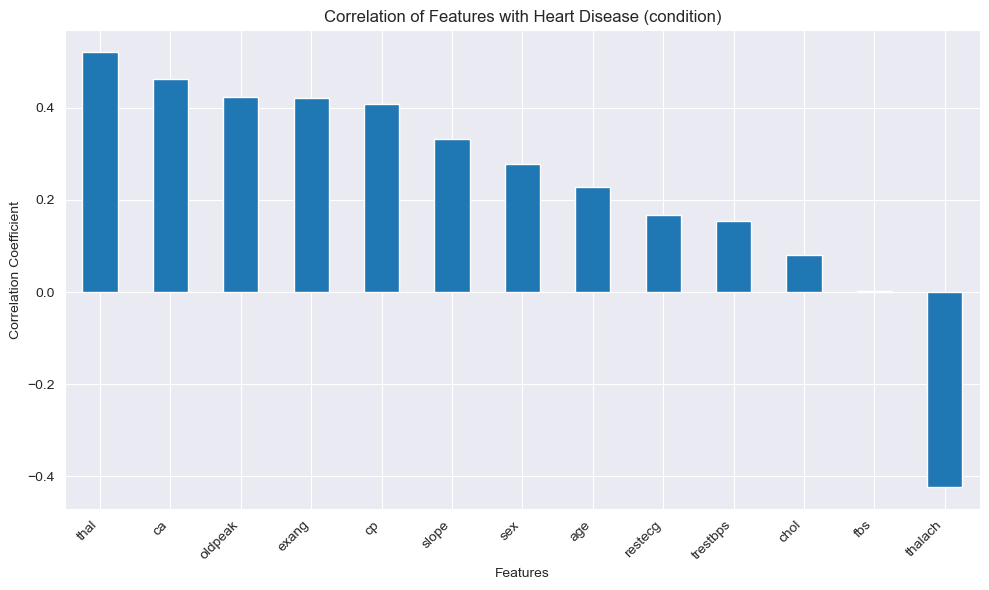

In [22]:
plt.figure(figsize=(10, 6))
data.corr(numeric_only=True)['condition'].drop('condition').sort_values(ascending=False).plot(kind='bar')
plt.title('Correlation of Features with Heart Disease (condition)')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Data Preprocessing

Based on the EDD processing thus far, several preprocessing steps are necessary to prepare the data for model building. These include:

1.  **Outlier Treatment:** Addressing outliers in numerical features.
2.  **Categorical Feature Encoding:** Converting categorical features into a numerical format suitable for machine learning models.
3.  **Feature Scaling:** Standardizing numerical features to ensure they contribute equally to the model.

### Outlier Treatment

In this section, I will treat outliers in `chol`, `trestbps`, `thalach` by capping values that fall outside the 1st and 99th percentiles. For `oldpeak`, which shoId high right-skewness and outliers, a log transformation might be more appropriate. HoIver, for simplicity and to maintain interpretability for this capstone project, I'll start with capping for all specified numerical features.

In [23]:
# Numerical columns identified with potential outliers
numerical_cols_with_outliers = ['chol', 'trestbps', 'thalach', 'oldpeak']

# Create a copy to avoid modifying the original DataFrame directly
data_processed = data.copy()

for col in numerical_cols_with_outliers:
    loIr_bound = data_processed[col].quantile(0.01)
    upper_bound = data_processed[col].quantile(0.99)

    data_processed[col] = np.where(data_processed[col] < loIr_bound, loIr_bound, data_processed[col])
    data_processed[col] = np.where(data_processed[col] > upper_bound, upper_bound, data_processed[col])

print("Outliers capped for numerical features (chol, trestbps, thalach, oldpeak).")

# Display descriptive statistics after capping to see the effect
print("\nDescriptive statistics after outlier capping:")
display(data_processed[numerical_cols_with_outliers].describe())

Outliers capped for numerical features (chol, trestbps, thalach, oldpeak).

Descriptive statistics after outlier capping:


,chol,trestbps,thalach,oldpeak
count,297.000000,297.000000,297.000000,297.000000
mean,246.943704,131.626263,149.668822,1.043515
std,49.019313,17.332550,22.504333,1.124033
min,148.680000,100.000000,94.800000,0.000000
25%,211.000000,120.000000,133.000000,0.000000
50%,243.000000,130.000000,153.000000,0.800000
75%,276.000000,140.000000,166.000000,1.600000
max,407.080000,180.000000,192.080000,4.208000


### Categorical Feature Encoding

This section will use One-Hot Encoding for the identified categorical features (`sex`, `cp`, `fbs`, `restecg`, `exang`, `slope`, `ca`, `thal`). The target variable `condition` is already binary (0 or 1), so it doesn't require encoding.

In [24]:
# Categorical columns to be one-hot encoded (excluding the target variable 'condition')
categorical_features_to_encode = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Apply One-Hot Encoding
data_processed = pd.get_dummies(data_processed, columns=categorical_features_to_encode, drop_first=True)
# 1. drop_first (column): True to avoid multicollinearity. False to avoid perfect correlation between encoded columns
# 2. It creates n-1 new columns instead of n. The first category is effectively dropped, becoming the reference category. This means that when all the n-1 remaining dummy variables are 0,

print("Categorical features successfully one-hot encoded.")
display(data_processed)

Categorical features successfully one-hot encoded.


,age,trestbps,chol,thalach,oldpeak,condition,sex_1,cp_1,cp_2,cp_3,...,restecg_1,restecg_2,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,thal_1,thal_2
0,69,160.0,234.0,131.0,0.1,0,True,False,False,False,...,False,True,False,True,False,True,False,False,False,False
1,69,140.0,239.0,151.0,1.8,0,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
2,66,150.0,226.0,114.0,2.6,0,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3,65,138.0,282.0,174.0,1.4,1,True,False,False,False,...,False,True,False,True,False,True,False,False,False,False
4,64,110.0,211.0,144.0,1.8,0,True,False,False,False,...,False,True,True,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,152.0,223.0,181.0,0.0,1,True,False,False,True,...,False,False,False,False,False,False,False,False,False,True
293,39,118.0,219.0,140.0,1.2,1,True,False,False,True,...,False,False,False,True,False,False,False,False,False,True
294,35,120.0,198.0,130.0,1.6,1,True,False,False,True,...,False,False,True,True,False,False,False,False,False,True
295,35,138.0,183.0,182.0,1.4,0,False,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [25]:
# Convert boolean columns to integers (0s and 1s) if preferred
# Identify boolean columns created by get_dummies
boolean_cols = data_processed.select_dtypes(include='bool').columns

# Convert them to int
for col in boolean_cols:
    data_processed[col] = data_processed[col].astype(int)

print("\nBoolean columns converted to integers (0 or 1).")
display(data_processed)


Boolean columns converted to integers (0 or 1).


,age,trestbps,chol,thalach,oldpeak,condition,sex_1,cp_1,cp_2,cp_3,...,restecg_1,restecg_2,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,thal_1,thal_2
0,69,160.0,234.0,131.0,0.1,0,1,0,0,0,...,0,1,0,1,0,1,0,0,0,0
1,69,140.0,239.0,151.0,1.8,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,66,150.0,226.0,114.0,2.6,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,65,138.0,282.0,174.0,1.4,1,1,0,0,0,...,0,1,0,1,0,1,0,0,0,0
4,64,110.0,211.0,144.0,1.8,0,1,0,0,0,...,0,1,1,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292,40,152.0,223.0,181.0,0.0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,1
293,39,118.0,219.0,140.0,1.2,1,1,0,0,1,...,0,0,0,1,0,0,0,0,0,1
294,35,120.0,198.0,130.0,1.6,1,1,0,0,1,...,0,0,1,1,0,0,0,0,0,1
295,35,138.0,183.0,182.0,1.4,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


### Feature Scaling

Finally, In this section, I will scale the remaining numerical features to ensure they are on a similar scale. This is important for many machine learning algorithms that are sensitive to the magnitude of feature values. I use `StandardScaler` from `scikit-learn`.

In [26]:
from sklearn.preprocessing import StandardScaler

# Identify numerical features that are not one-hot encoded (i.e., the original numerical features excluding the target)
# and haven't been removed or became part of the categorical encoding process.

# Get a list of numerical columns after outlier treatment but before one-hot encoding.
original_numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# The 'condition' column is the target and will not be scaled with features.
features_to_scale = [col for col in original_numerical_cols if col in data_processed.columns]

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to the identified numerical features
data_processed[features_to_scale] = scaler.fit_transform(data_processed[features_to_scale])

print("Numerical features successfully scaled using StandardScaler.")
print("\nFirst 5 rows of the DataFrame after feature scaling:")
display(data_processed.head())

Numerical features successfully scaled using StandardScaler.

First 5 rows of the DataFrame after feature scaling:


,age,trestbps,chol,thalach,oldpeak,condition,sex_1,cp_1,cp_2,cp_3,...,restecg_1,restecg_2,exang_1,slope_1,slope_2,ca_1,ca_2,ca_3,thal_1,thal_2
0,1.600302,1.639783,-0.264499,-0.830966,-0.840818,0,1,0,0,0,...,0,1,0,1,0,1,0,0,0,0
1,1.600302,0.483937,-0.162326,0.059252,0.674145,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0
2,1.268242,1.061860,-0.427975,-1.587651,1.387069,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
3,1.157555,0.368353,0.716360,1.083002,0.317683,1,1,0,0,0,...,0,1,0,1,0,1,0,0,0,0
4,1.046868,-1.249831,-0.734494,-0.252324,0.674145,0,1,0,0,0,...,0,1,1,1,0,0,0,0,0,0


# Conclusion
Now that the data has been thoroughly preprocessed, including outlier treatment, categorical feature encoding, and feature scaling, it's ready for model building.

The next phase of this code will focus on splitting the data into training and testing sets, select appropriate machine learning models (scikit-learn offers many options like Logistic Regression, Random Forest, etc.), train them, and evaluate their performance. This will help determine the predictive power of the dataset for the Heart Disease Risk Prediction model.